# Clustering Music Genres 

Bu projenin amacı şarkıların ses özelliklerine göre benzerliklerini analiz etmek ve bu doğrultuda anlamlı gruplar (kümeler) oluşturmaktır. Spotify’dan elde edilen veri setinde yer alan şarkıların çeşitli akustik özellikleri kullanılarak kümeleme algoritmaları uygulanacak ve benzer yapıya sahip müzikler aynı gruplar altında toplanacaktır.

In [1]:
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv('Spotify-2000.csv')

In [3]:
df.head()

,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Index                   1994 non-null   int64 
 1   Title                   1994 non-null   object
 2   Artist                  1994 non-null   object
 3   Top Genre               1994 non-null   object
 4   Year                    1994 non-null   int64 
 5   Beats Per Minute (BPM)  1994 non-null   int64 
 6   Energy                  1994 non-null   int64 
 7   Danceability            1994 non-null   int64 
 8   Loudness (dB)           1994 non-null   int64 
 9   Liveness                1994 non-null   int64 
 10  Valence                 1994 non-null   int64 
 11  Length (Duration)       1994 non-null   object
 12  Acousticness            1994 non-null   int64 
 13  Speechiness             1994 non-null   int64 
 14  Popularity              1994 non-null   int64 
dtypes: i

In [5]:
df['Year'].value_counts()

Year
2008    54
2018    52
1991    52
1977    51
2002    47
        ..
1962     3
1959     3
1960     1
1961     1
1956     1
Name: count, Length: 63, dtype: int64

In [6]:
df['Top Genre'].value_counts()

Top Genre
album rock                 413
adult standards            123
dutch pop                   88
alternative rock            86
dance pop                   83
                          ... 
german alternative rock      1
classic italian pop          1
pop punk                     1
motown                       1
bebop                        1
Name: count, Length: 149, dtype: int64

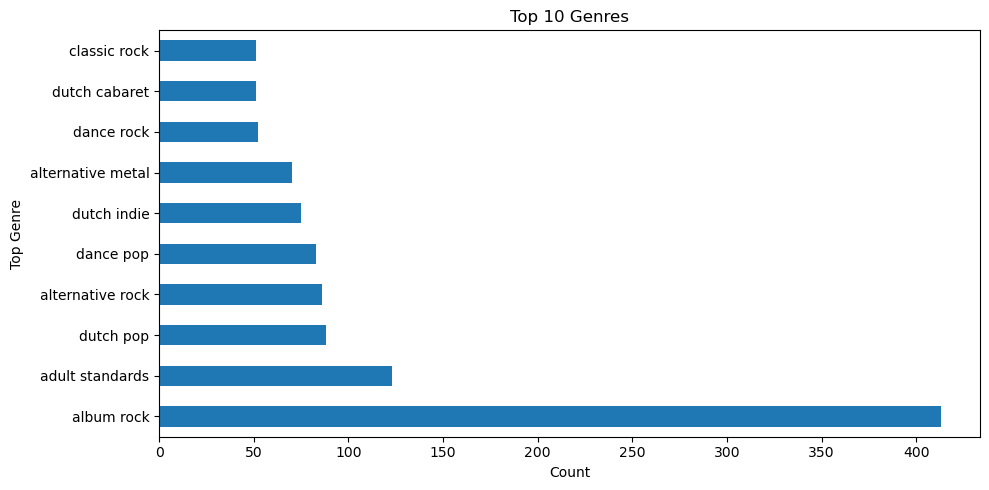

In [7]:
# Top Genres Distribution
plt.figure(figsize=(10, 5))
df['Top Genre'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

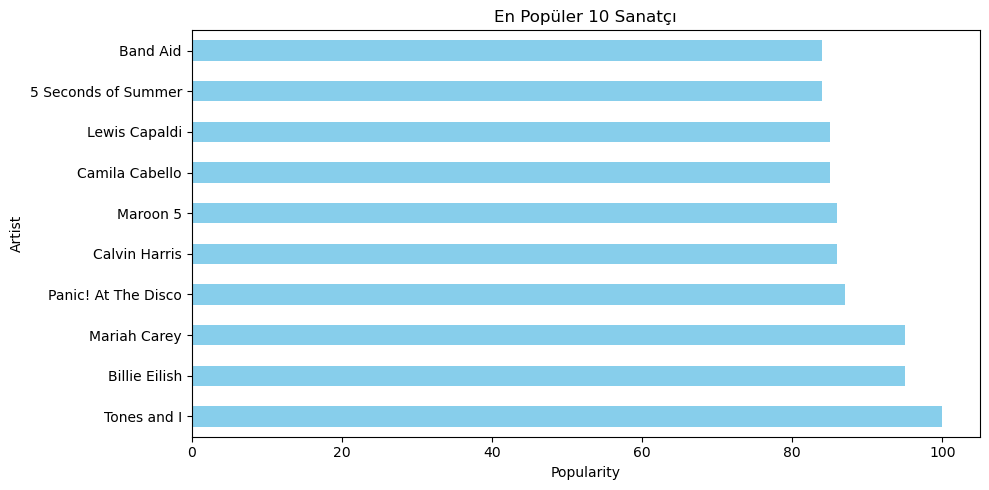

In [8]:
#En Popüler Sanatçılar
plt.figure(figsize=(10, 5))
df.groupby('Artist')['Popularity'].mean().nlargest(10).plot(kind='barh', color='skyblue')
plt.title('En Popüler 10 Sanatçı')
plt.xlabel('Popularity')
plt.tight_layout()
plt.show()

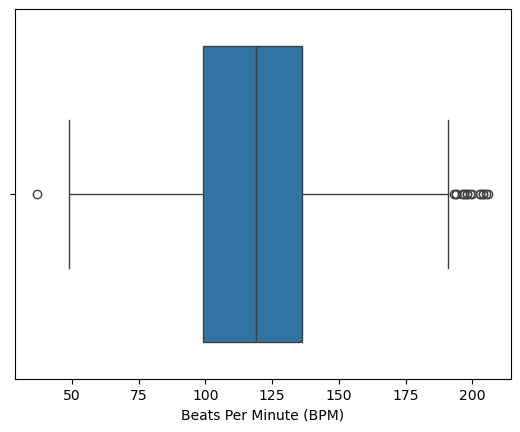

In [9]:
sns.boxplot(x=df['Beats Per Minute (BPM)']);  

In [10]:
#df['Length (Duration)'].mean()+3*df['Length (Duration)'].std()

In [11]:
#Beats Per Minute (BPM) dakika başına vuruş değer arttıkça şarkı hızlanıyor yüksek değeri enerjik ve dans düşük sakin ve yaşan şarkılar
df['Length (Duration)'].value_counts()

Length (Duration)
215      23
243      21
217      20
241      20
236      20
         ..
450       1
449       1
1,292     1
119       1
128       1
Name: count, Length: 350, dtype: int64

In [12]:
# 'Length (Duration)' kolonunu sayısal hale getirelim
df['Length (Duration)'] = df['Length (Duration)'].astype(str).str.replace(',', '').astype(int)

In [13]:
df.describe()

,Index,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.00000
mean,997.500000,1992.992979,120.215647,59.679539,53.238215,-9.008526,19.012036,49.408726,262.443330,28.858074,4.994985,59.52658
std,575.762538,16.116048,28.028096,22.154322,15.351507,3.647876,16.727378,24.858212,93.604387,29.011986,4.401566,14.35160
min,1.000000,1956.000000,37.000000,3.000000,10.000000,-27.000000,2.000000,3.000000,93.000000,0.000000,2.000000,11.00000
25%,499.250000,1979.000000,99.000000,42.000000,43.000000,-11.000000,9.000000,29.000000,212.000000,3.000000,3.000000,49.25000
50%,997.500000,1993.000000,119.000000,61.000000,53.000000,-8.000000,12.000000,47.000000,245.000000,18.000000,4.000000,62.00000
75%,1495.750000,2007.000000,136.000000,78.000000,64.000000,-6.000000,23.000000,69.750000,289.000000,50.000000,5.000000,71.00000
max,1994.000000,2019.000000,206.000000,100.000000,96.000000,-2.000000,99.000000,99.000000,1412.000000,99.000000,55.000000,100.00000


In [14]:
df['Length (Duration)'].describe()

count    1994.000000
mean      262.443330
std        93.604387
min        93.000000
25%       212.000000
50%       245.000000
75%       289.000000
max      1412.000000
Name: Length (Duration), dtype: float64

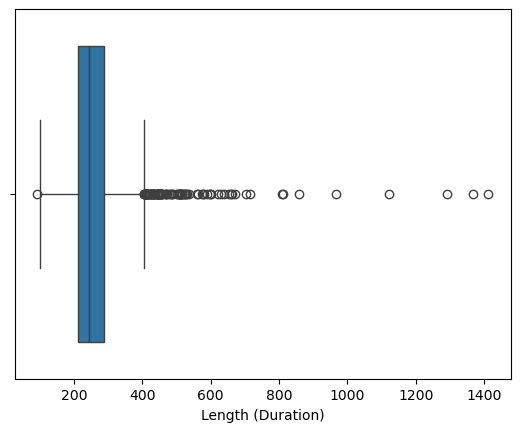

In [15]:
sns.boxplot(x=df['Length (Duration)']);  

In [16]:
#df['Length (Duration)'].mean()+3*df['Length (Duration)'].std()

In [17]:
df.Energy.describe()

count    1994.000000
mean       59.679539
std        22.154322
min         3.000000
25%        42.000000
50%        61.000000
75%        78.000000
max       100.000000
Name: Energy, dtype: float64

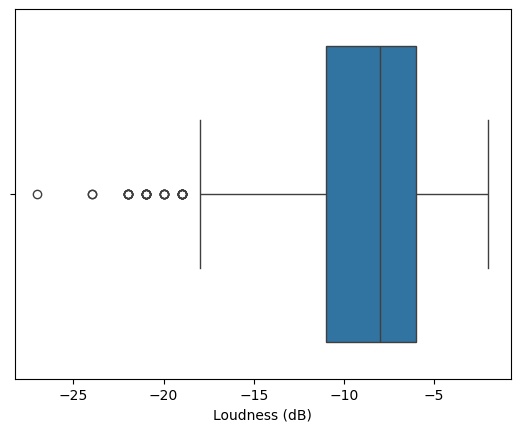

In [18]:
sns.boxplot(x=df['Loudness (dB)']);  #Loudness (Ses Yüksekliği/Şiddeti), bir sesin insan kulağı tarafından algılanan şiddetini ifade eder

In [19]:
#df['Loudness (dB)'].mean()+3*df['Loudness (dB)'].std()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Index                   1994 non-null   int64 
 1   Title                   1994 non-null   object
 2   Artist                  1994 non-null   object
 3   Top Genre               1994 non-null   object
 4   Year                    1994 non-null   int64 
 5   Beats Per Minute (BPM)  1994 non-null   int64 
 6   Energy                  1994 non-null   int64 
 7   Danceability            1994 non-null   int64 
 8   Loudness (dB)           1994 non-null   int64 
 9   Liveness                1994 non-null   int64 
 10  Valence                 1994 non-null   int64 
 11  Length (Duration)       1994 non-null   int64 
 12  Acousticness            1994 non-null   int64 
 13  Speechiness             1994 non-null   int64 
 14  Popularity              1994 non-null   int64 
dtypes: i

In [21]:
x=df[['Energy', 
    'Danceability', 
    'Loudness (dB)', 
    'Liveness',
    'Valence', 
    'Acousticness', 
    'Beats Per Minute (BPM)',
    'Length (Duration)',
    'Popularity',
    'Liveness', 
    'Speechiness',
    'Top Genre']]

In [22]:
x=pd.get_dummies(x, drop_first=True)

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [24]:
model=KMeans(4)      #Burada 4 gruba ayırıyoruz

In [25]:
model=model.fit(x)

In [26]:
tahmin=model.predict(x)

In [27]:
x['Music Segments']=tahmin

In [28]:
x.head()

,Energy,Danceability,Loudness (dB),Liveness,Valence,Acousticness,Beats Per Minute (BPM),Length (Duration),Popularity,Liveness,...,Top Genre_reggae fusion,Top Genre_rock-and-roll,Top Genre_scottish singer-songwriter,Top Genre_soft rock,Top Genre_stomp and holler,Top Genre_streektaal,Top Genre_trance,Top Genre_uk pop,Top Genre_yacht rock,Music Segments
0,30,53,-14,11,68,94,157,201,71,11,...,False,False,False,False,False,False,False,False,False,0
1,79,50,-11,17,81,17,135,207,39,17,...,False,False,False,False,False,False,False,False,False,0
2,69,66,-9,7,52,2,168,341,69,7,...,False,False,False,False,False,False,False,False,False,3
3,96,43,-4,3,37,0,173,269,76,3,...,False,False,False,False,False,False,False,False,False,3
4,82,58,-5,10,87,1,106,256,59,10,...,False,False,False,False,False,False,False,False,False,3


In [29]:
import plotly.graph_objects as go

PLOT = go.Figure()

for i in list(x["Music Segments"].unique()):
    PLOT.add_trace(go.Scatter3d(
        x=x[x["Music Segments"] == i]['Beats Per Minute (BPM)'],
        y=x[x["Music Segments"] == i]['Energy'],
        z=x[x["Music Segments"] == i]['Danceability'],
        mode='markers',
        marker_size=6,
        marker_line_width=1,
        name=str(i)
    ))

PLOT.update_traces(hovertemplate='Beats Per Minute (BPM): %{x} <br>Energy: %{y} <br>Danceability: %{z}')

PLOT.update_layout(
    width=800,
    height=800,
    autosize=True,
    showlegend=True,
    scene=dict(
        xaxis=dict(
            title=dict(text='Beats Per Minute (BPM)', font=dict(color='black'))
        ),
        yaxis=dict(
            title=dict(text='Energy', font=dict(color='black'))
        ),
        zaxis=dict(
            title=dict(text='Danceability', font=dict(color='black'))
        )
    ),
    font=dict(family="Gilroy", color='black', size=12)
)

<Axes: xlabel='Music Segments', ylabel='count'>

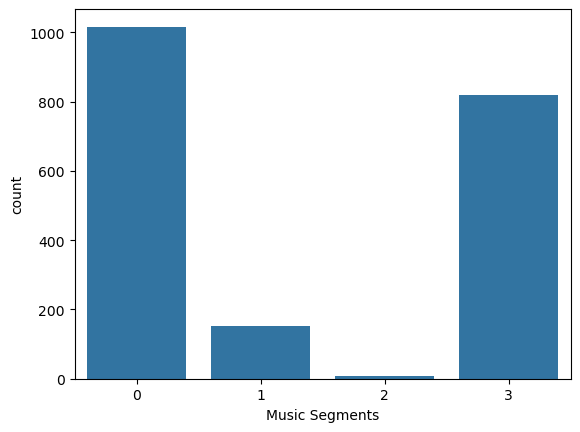

In [30]:
sns.countplot(x=x['Music Segments'])

In [31]:
silhouette_score(x,tahmin)

0.22481985033984847

In [32]:
from yellowbrick.cluster import KElbowVisualizer

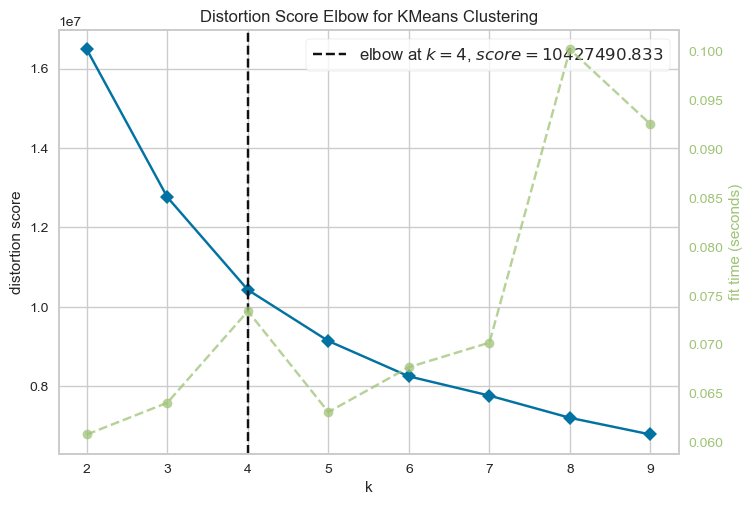

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [33]:
vis=KElbowVisualizer(KMeans(), k=(2,10))           #zaten datayı gruplara ayıracağımız için 1e bölmek demek datanın kendisine bölmek oluyor
vis.fit(x)
vis.show()

In [34]:
#wcss= within cluster sum of squares uzaklıkları hesaplayarak türev alarak en optimum uzaklığı buluyor yer seçimi için inceleyebiliriz
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(x)
    tahmin=model.predict(x)
    ss1=silhouette_score(x,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.5180004878750326
0.3185903386087524
0.21729080093021302
0.21391347593592508
0.1913084873780943
0.1913329470372248
0.16413999489428638
0.16608174444142593


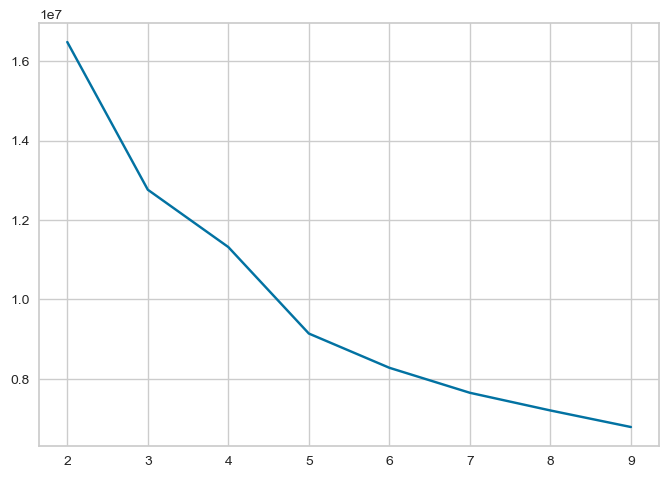

In [35]:
plt.plot(range(2,10), wcss)   #dirsek nerede kırılırsa optimum grup o kadardır.

In [36]:
## Hierarchical Clustering 

In [37]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [38]:
data=linkage(x,method='ward',metric='euclidean')

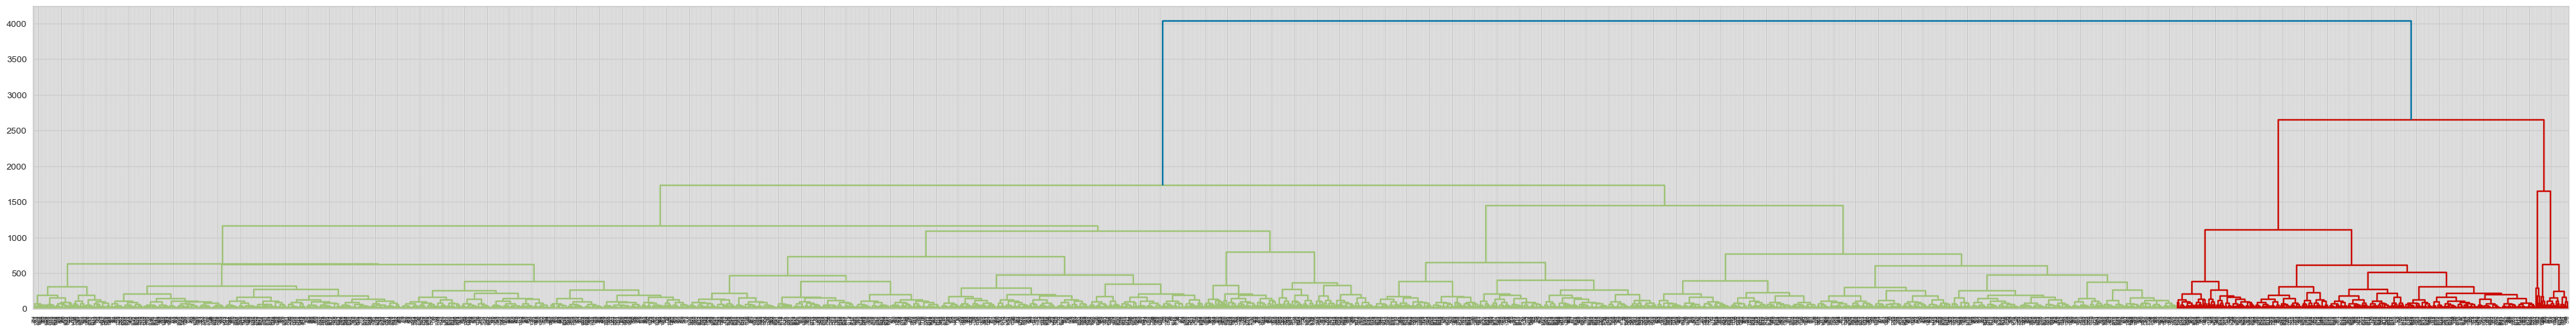

In [39]:
plt.figure(figsize=(50,6))
dendrogram(data);

In [40]:
x['Title']=df['Title']
x['Artist']=df['Artist']
x['Top Genre']=df['Top Genre']

In [41]:
x.head()

,Energy,Danceability,Loudness (dB),Liveness,Valence,Acousticness,Beats Per Minute (BPM),Length (Duration),Popularity,Liveness,...,Top Genre_soft rock,Top Genre_stomp and holler,Top Genre_streektaal,Top Genre_trance,Top Genre_uk pop,Top Genre_yacht rock,Music Segments,Title,Artist,Top Genre
0,30,53,-14,11,68,94,157,201,71,11,...,False,False,False,False,False,False,0,Sunrise,Norah Jones,adult standards
1,79,50,-11,17,81,17,135,207,39,17,...,False,False,False,False,False,False,0,Black Night,Deep Purple,album rock
2,69,66,-9,7,52,2,168,341,69,7,...,False,False,False,False,False,False,3,Clint Eastwood,Gorillaz,alternative hip hop
3,96,43,-4,3,37,0,173,269,76,3,...,False,False,False,False,False,False,3,The Pretender,Foo Fighters,alternative metal
4,82,58,-5,10,87,1,106,256,59,10,...,False,False,False,False,False,False,3,Waitin' On A Sunny Day,Bruce Springsteen,classic rock


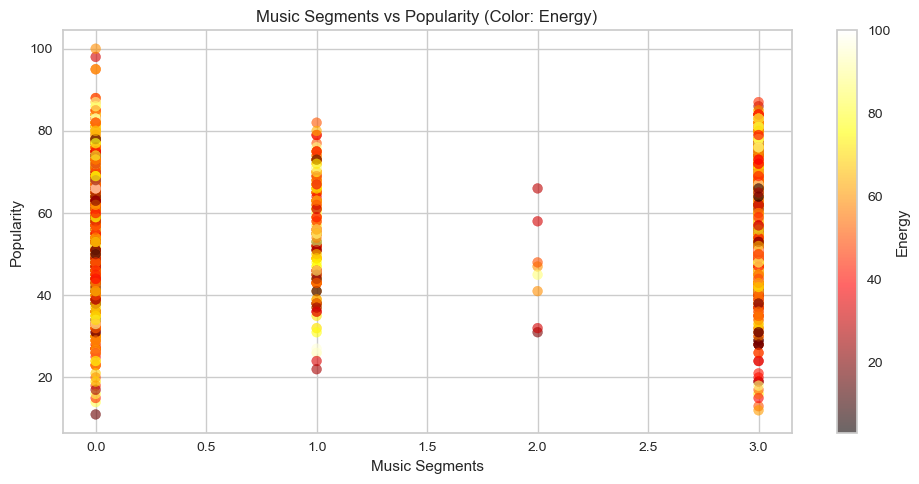

In [42]:
# Scatter: Segments vs Popularity
plt.figure(figsize=(10, 5))
plt.scatter(x['Music Segments'],x['Popularity'], alpha=0.6, c=x['Energy'], cmap='hot', s=50)
plt.xlabel('Music Segments')
plt.ylabel('Popularity')
plt.title('Music Segments vs Popularity (Color: Energy)')
plt.colorbar(label='Energy')
plt.tight_layout()
plt.show()